# Notebook 06: OOF + Early Stopping EfficientNet-B0 + DenseNet121 Ensemble

This version is designed to fight overfitting with:
- 5-fold stratified OOF validation
- early stopping
- higher dropout in the head
- simpler, more medical-safe augmentation
- threshold selection from OOF predictions instead of one split


---
## Step 1: Imports


In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    densenet121,
    efficientnet_b0,
)
from tqdm.auto import tqdm

print("Imports OK")


Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and device


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")


Device: mps


## Step 3: Configuration


In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 0
N_FOLDS = 5
EPOCHS = 10
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 1e-4
LR = 1e-3
MOMENTUM = 0.9
NESTEROV = True
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
TRAIN_EFNET_WEIGHT = 0.5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"IMG_SIZE                : {IMG_SIZE}")
print(f"BATCH_SIZE              : {BATCH_SIZE}")
print(f"N_FOLDS                 : {N_FOLDS}")
print(f"EPOCHS                  : {EPOCHS}")
print(f"EARLY_STOPPING_PATIENCE : {EARLY_STOPPING_PATIENCE}")
print(f"LR                      : {LR}")
print(f"MOMENTUM                : {MOMENTUM}")
print(f"NESTEROV                : {NESTEROV}")
print(f"WEIGHT_DECAY            : {WEIGHT_DECAY}")
print(f"DROPOUT                 : {DROPOUT}")
print(f"TRAIN_EFNET_WEIGHT      : {TRAIN_EFNET_WEIGHT}")


IMG_SIZE                : 256
BATCH_SIZE              : 4
N_FOLDS                 : 5
EPOCHS                  : 10
EARLY_STOPPING_PATIENCE : 2
LR                      : 0.001
MOMENTUM                : 0.9
NESTEROV                : True
WEIGHT_DECAY            : 0.0001
DROPOUT                 : 0.5
TRAIN_EFNET_WEIGHT      : 0.5


## Step 4: Load labels


In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)
df = df.reset_index(drop=True)
print(df[["image_file", "label"]].head())
print(df["label"].value_counts())


       image_file  label
0  IMG_000838.png      1
1  IMG_000239.png      1
2  IMG_000217.png      0
3  IMG_001193.png      0
4  IMG_001097.png      0
label
0    858
1    720
Name: count, dtype: int64


## Step 5: Dataset


In [5]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["image_file"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        if self.return_label:
            label = torch.tensor(float(row["label"]), dtype=torch.float32)
            return img, label
        return img, row["image_file"]


## Step 6: Stratified folds


In [6]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
df["fold"] = -1
for fold, (_, val_idx) in enumerate(skf.split(df, df["label"])):
    df.loc[val_idx, "fold"] = fold

print(df.groupby("fold")["label"].agg(["count", "mean"]))


      count      mean
fold                 
0       316  0.455696
1       316  0.455696
2       316  0.455696
3       315  0.457143
4       315  0.457143


## Step 7: Transforms and loader helpers


In [7]:
def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=3),
            T.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)

def make_loaders(train_df, val_df):
    train_tf = build_transform(IMG_SIZE, augment=True)
    eval_tf = build_transform(IMG_SIZE, augment=False)

    train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
    train_eval_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=eval_tf)
    val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=eval_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )
    train_eval_loader = DataLoader(
        train_eval_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )
    return train_loader, train_eval_loader, val_loader


## Step 8: Metrics helpers


In [8]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)

    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())

    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold_score(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    best_thr, best_score = 0.5, -1.0
    for thr in np.linspace(0.01, 0.99, 199):
        sens, spec = sens_spec(y_true, y_prob, threshold=thr)
        score = datathon_score(auroc, sens, spec)
        if score > best_score:
            best_thr, best_score = thr, score
    return best_thr, best_score


## Step 9: Joint ensemble model


In [9]:
class EfficientDenseEnsemble(nn.Module):
    def __init__(self, dropout=DROPOUT, efnet_weight=TRAIN_EFNET_WEIGHT):
        super().__init__()
        self.efnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        ef_in = self.efnet.classifier[1].in_features
        self.efnet.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(ef_in, 1))

        self.efnet_weight = efnet_weight

        self.dnet = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        dn_in = self.dnet.classifier.in_features
        self.dnet.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(dn_in, 1))

    def forward_logits(self, x):
        ef_logits = self.efnet(x).squeeze(1)
        dn_logits = self.dnet(x).squeeze(1)
        return ef_logits, dn_logits

    def forward(self, x, efnet_weight=None):
        ef_logits, dn_logits = self.forward_logits(x)
        w = self.efnet_weight if efnet_weight is None else efnet_weight
        return w * ef_logits + (1.0 - w) * dn_logits


## Step 10: Train / eval helpers


In [10]:
@torch.no_grad()
def evaluate(model, loader, device, efnet_weight=TRAIN_EFNET_WEIGHT):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs, efnet_weight=efnet_weight)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys)
    ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}

@torch.no_grad()
def predict_branch_probs(model, loader, device):
    model.eval()
    ys, ef_ps, dn_ps = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        ef_logits, dn_logits = model.forward_logits(imgs)
        ef_probs = torch.sigmoid(ef_logits).detach().cpu().numpy()
        dn_probs = torch.sigmoid(dn_logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ef_ps.extend(ef_probs.tolist())
        dn_ps.extend(dn_probs.tolist())
    return np.array(ys), np.array(ef_ps), np.array(dn_ps)

@torch.no_grad()
def predict_branch_probs_test(model, loader, device):
    model.eval()
    names, ef_ps, dn_ps = [], [], []
    for imgs, batch_names in loader:
        imgs = imgs.to(device)
        ef_logits, dn_logits = model.forward_logits(imgs)
        ef_probs = torch.sigmoid(ef_logits).detach().cpu().numpy()
        dn_probs = torch.sigmoid(dn_logits).detach().cpu().numpy()
        names.extend(batch_names)
        ef_ps.extend(ef_probs.tolist())
        dn_ps.extend(dn_probs.tolist())
    return names, np.array(ef_ps), np.array(dn_ps)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train_fold(model, train_loader, val_loader, train_pos_weight, optimizer, scheduler, epochs, device, tag="ensemble"):
    pos_weight = torch.tensor([train_pos_weight], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best = {"score": -1.0, "state": None, "epoch": 0, "thr": 0.5}
    history = []
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        thr, tuned_score = best_threshold_score(val["y"], val["p"])
        sens_t, spec_t = sens_spec(val["y"], val["p"], threshold=thr)
        dt = time.time() - t0

        history.append({
            "epoch": epoch,
            "loss": tr_loss,
            "auroc": val["auroc"],
            "sens": sens_t,
            "spec": spec_t,
            "thr": thr,
            "score": tuned_score,
        })

        improved = tuned_score > (best["score"] + EARLY_STOPPING_MIN_DELTA)
        star = ""
        if improved:
            best = {
                "score": tuned_score,
                "auroc": val["auroc"],
                "sens": sens_t,
                "spec": spec_t,
                "thr": thr,
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
            }
            patience_left = EARLY_STOPPING_PATIENCE
            star = " ★"
        else:
            patience_left -= 1

        scheduler.step()
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {sens_t:.3f}  spec {spec_t:.3f}  "
            f"score {tuned_score:.4f}  thr {thr:.3f}  patience {patience_left}  ({dt:.1f}s){star}"
        )

        if patience_left < 0:
            print(f"[{tag}] early stopping triggered at epoch {epoch}")
            break

    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best


## Step 11: Run 5-fold training


In [11]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Test images: {len(test_ds)}")

oof_ef = np.zeros(len(df), dtype=np.float32)
oof_dn = np.zeros(len(df), dtype=np.float32)
oof_y = df["label"].to_numpy().astype(np.float32)
fold_histories = {}
fold_rows = []
test_ef_folds = []
test_dn_folds = []
last_test_names = None

for fold in range(N_FOLDS):
    train_fold_df = df[df["fold"] != fold].reset_index(drop=True)
    val_fold_df = df[df["fold"] == fold].copy()
    val_indices = val_fold_df.index.to_numpy()
    val_fold_df = val_fold_df.reset_index(drop=True)

    print()
    print(f"===== Fold {fold + 1}/{N_FOLDS} =====")
    print(f"Train: {len(train_fold_df)}  (pos rate {train_fold_df['label'].mean():.3f})")
    print(f"Val  : {len(val_fold_df)}  (pos rate {val_fold_df['label'].mean():.3f})")

    train_loader, train_eval_loader, val_loader = make_loaders(train_fold_df, val_fold_df)
    model = EfficientDenseEnsemble(dropout=DROPOUT).to(device)

    optimizer = optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        nesterov=NESTEROV,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    pos_weight = train_fold_df["label"].eq(0).sum() / train_fold_df["label"].eq(1).sum()

    model, history_df, best = train_fold(
        model,
        train_loader,
        val_loader,
        train_pos_weight=pos_weight,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=EPOCHS,
        device=device,
        tag=f"fold_{fold}",
    )
    fold_histories[fold] = history_df

    train_eval = evaluate(model, train_eval_loader, device)
    train_thr, train_score = best_threshold_score(train_eval["y"], train_eval["p"])
    train_sens, train_spec = sens_spec(train_eval["y"], train_eval["p"], threshold=train_thr)

    val_eval = evaluate(model, val_loader, device)
    val_thr, val_score = best_threshold_score(val_eval["y"], val_eval["p"])
    val_sens, val_spec = sens_spec(val_eval["y"], val_eval["p"], threshold=val_thr)

    y_val, ef_val_probs, dn_val_probs = predict_branch_probs(model, val_loader, device)
    oof_ef[val_indices] = ef_val_probs
    oof_dn[val_indices] = dn_val_probs

    test_names, ef_test_probs, dn_test_probs = predict_branch_probs_test(model, test_loader, device)
    last_test_names = test_names
    test_ef_folds.append(ef_test_probs)
    test_dn_folds.append(dn_test_probs)

    fold_rows.append({
        "fold": fold,
        "best_epoch": best["epoch"],
        "train_score": train_score,
        "train_auroc": train_eval["auroc"],
        "train_sens": train_sens,
        "train_spec": train_spec,
        "val_score": val_score,
        "val_auroc": val_eval["auroc"],
        "val_sens": val_sens,
        "val_spec": val_spec,
        "score_gap": train_score - val_score,
        "auroc_gap": train_eval["auroc"] - val_eval["auroc"],
    })

fold_summary_df = pd.DataFrame(fold_rows)
fold_summary_df


Test images: 176

===== Fold 1/5 =====
Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)


[fold_0] ep 01/10  loss 0.7011  AUROC 0.8499  sens 0.903  spec 0.674  score 0.8193  thr 0.361  patience 2  (107.7s) ★


[fold_0] ep 02/10  loss 0.6108  AUROC 0.8811  sens 0.854  spec 0.762  score 0.8445  thr 0.609  patience 2  (98.2s) ★


[fold_0] ep 03/10  loss 0.5527  AUROC 0.8965  sens 0.868  spec 0.773  score 0.8586  thr 0.485  patience 2  (98.5s) ★


[fold_0] ep 04/10  loss 0.5442  AUROC 0.9195  sens 0.875  spec 0.826  score 0.8849  thr 0.277  patience 2  (100.2s) ★


...

[fold_4] ep 07/10  loss 0.4007  AUROC 0.9124  sens 0.792  spec 0.906  score 0.8807  thr 0.792  patience 2  (96.0s) ★


[fold_4] ep 08/10  loss 0.3865  AUROC 0.9166  sens 0.819  spec 0.877  score 0.8825  thr 0.584  patience 2  (96.5s) ★


[fold_4] ep 09/10  loss 0.3857  AUROC 0.9176  sens 0.799  spec 0.906  score 0.8851  thr 0.574  patience 2  (96.5s) ★


[fold_4] ep 10/10  loss 0.3638  AUROC 0.9155  sens 0.792  spec 0.901  score 0.8808  thr 0.475  patience 1  (95.0s)


,fold,best_epoch,train_score,train_auroc,train_sens,train_spec,val_score,val_auroc,val_sens,val_spec,score_gap,auroc_gap
0,0,8,0.964839,0.984383,0.972222,0.918367,0.897428,0.933099,0.944444,0.779070,0.067411,0.051283
1,1,4,0.910412,0.943991,0.881944,0.871720,0.868116,0.887153,0.895833,0.802326,0.042296,0.056839
2,2,10,0.972917,0.990998,0.954861,0.954810,0.895006,0.928658,0.868056,0.854651,0.077911,0.062340
3,3,6,0.949128,0.976427,0.906250,0.937409,0.908321,0.937622,0.875000,0.883041,0.040807,0.038805
4,4,9,0.976887,0.993109,0.963542,0.957787,0.885061,0.917601,0.798611,0.906433,0.091825,0.075508


## Step 12: Fold diagnostics and overfitting check


 fold  best_epoch  train_score  train_auroc  train_sens  train_spec  val_score  val_auroc  val_sens  val_spec  score_gap  auroc_gap
    0           8     0.964839     0.984383    0.972222    0.918367   0.897428   0.933099  0.944444  0.779070   0.067411   0.051283
    1           4     0.910412     0.943991    0.881944    0.871720   0.868116   0.887153  0.895833  0.802326   0.042296   0.056839
    2          10     0.972917     0.990998    0.954861    0.954810   0.895006   0.928658  0.868056  0.854651   0.077911   0.062340
    3           6     0.949128     0.976427    0.906250    0.937409   0.908321   0.937622  0.875000  0.883041   0.040807   0.038805
    4           9     0.976887     0.993109    0.963542    0.957787   0.885061   0.917601  0.798611  0.906433   0.091825   0.075508

Average across folds:
train_score    0.954836
train_auroc    0.977782
train_sens     0.935764
train_spec     0.928019
val_score      0.890786
val_auroc      0.920826
val_sens       0.876389
val_spec       0.

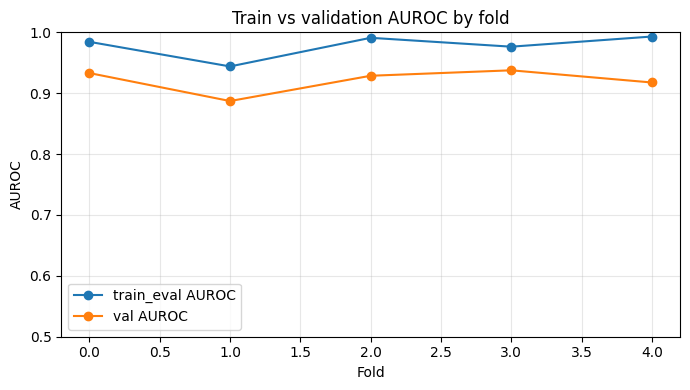

In [12]:
print(fold_summary_df.to_string(index=False))

print("\nAverage across folds:")
print(fold_summary_df.drop(columns=["fold", "best_epoch"]).mean().to_string())

plt.figure(figsize=(7, 4))
plt.plot(fold_summary_df["fold"], fold_summary_df["train_auroc"], marker="o", label="train_eval AUROC")
plt.plot(fold_summary_df["fold"], fold_summary_df["val_auroc"], marker="o", label="val AUROC")
plt.xlabel("Fold")
plt.ylabel("AUROC")
plt.title("Train vs validation AUROC by fold")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Step 13: OOF ROC and robust threshold selection


           mode  efnet_weight  densenet_weight     thr    score    auroc     sens     spec
5fold_oof_50_50           0.5              0.5 0.59404 0.878284 0.907349 0.856944 0.841492


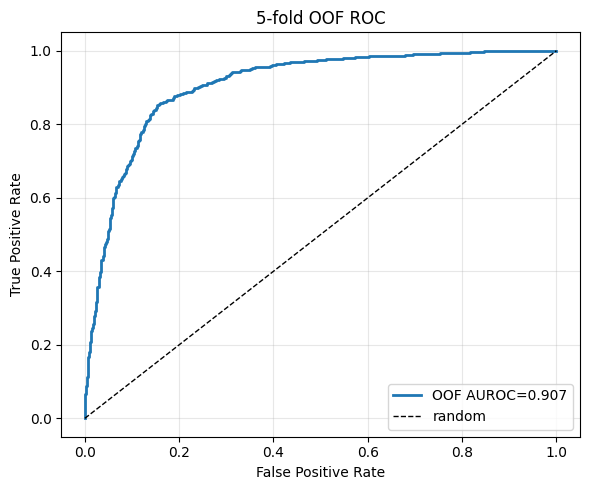

In [13]:
oof_probs = TRAIN_EFNET_WEIGHT * oof_ef + (1.0 - TRAIN_EFNET_WEIGHT) * oof_dn
oof_thr, oof_score = best_threshold_score(oof_y, oof_probs)
oof_auroc = roc_auc_score(oof_y, oof_probs)
oof_sens, oof_spec = sens_spec(oof_y, oof_probs, threshold=oof_thr)

oof_summary_df = pd.DataFrame([
    {
        "mode": "5fold_oof_50_50",
        "efnet_weight": TRAIN_EFNET_WEIGHT,
        "densenet_weight": 1.0 - TRAIN_EFNET_WEIGHT,
        "thr": oof_thr,
        "score": oof_score,
        "auroc": oof_auroc,
        "sens": oof_sens,
        "spec": oof_spec,
    }
])
print(oof_summary_df.to_string(index=False))

plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(oof_y, oof_probs)
plt.plot(fpr, tpr, lw=2, label=f"OOF AUROC={oof_auroc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5-fold OOF ROC")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 14: Submission CSV from fold ensemble + OOF threshold


In [14]:
mean_test_ef = np.mean(np.stack(test_ef_folds, axis=0), axis=0)
mean_test_dn = np.mean(np.stack(test_dn_folds, axis=0), axis=0)
all_probs = TRAIN_EFNET_WEIGHT * mean_test_ef + (1.0 - TRAIN_EFNET_WEIGHT) * mean_test_dn

sub = pd.DataFrame({
    "image_file": last_test_names,
    "prob": all_probs,
})
sub["pred"] = (sub["prob"] >= oof_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_06_oof_5050_efnet_densenet_{stamp}.csv"
sub.to_csv(out_path, index=False)

print(f"\nUsing OOF threshold: {oof_thr:.3f}")
print(f"Wrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")



Using OOF threshold: 0.594
Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_06_oof_5050_efnet_densenet_20260421_2217.csv
       image_file      prob  pred
0  IMG_000018.png  0.718771     1
1  IMG_000021.png  0.224332     0
2  IMG_000039.png  0.433609     0
3  IMG_000044.png  0.315266     0
4  IMG_000047.png  0.588870     0

Positive rate in submission: 0.403
